Initial rows: 288337
Rows after cleaning: 288107
Rows removed: 230
Saved:
azul_route_seasonality_outputs\route_monthly_demand_cleaned.csv
azul_route_seasonality_outputs\route_seasonality_summary_cleaned.csv
azul_route_seasonality_outputs\route_peak_tow_review.csv
azul_route_seasonality_outputs\route_month_equipment_tow_mix.csv


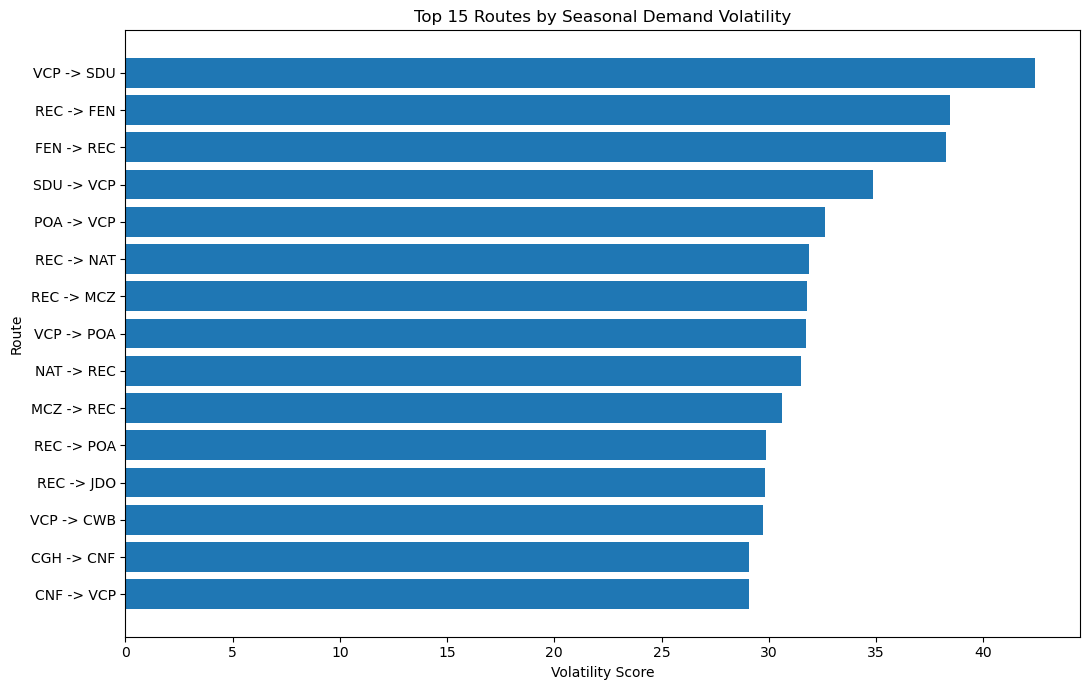

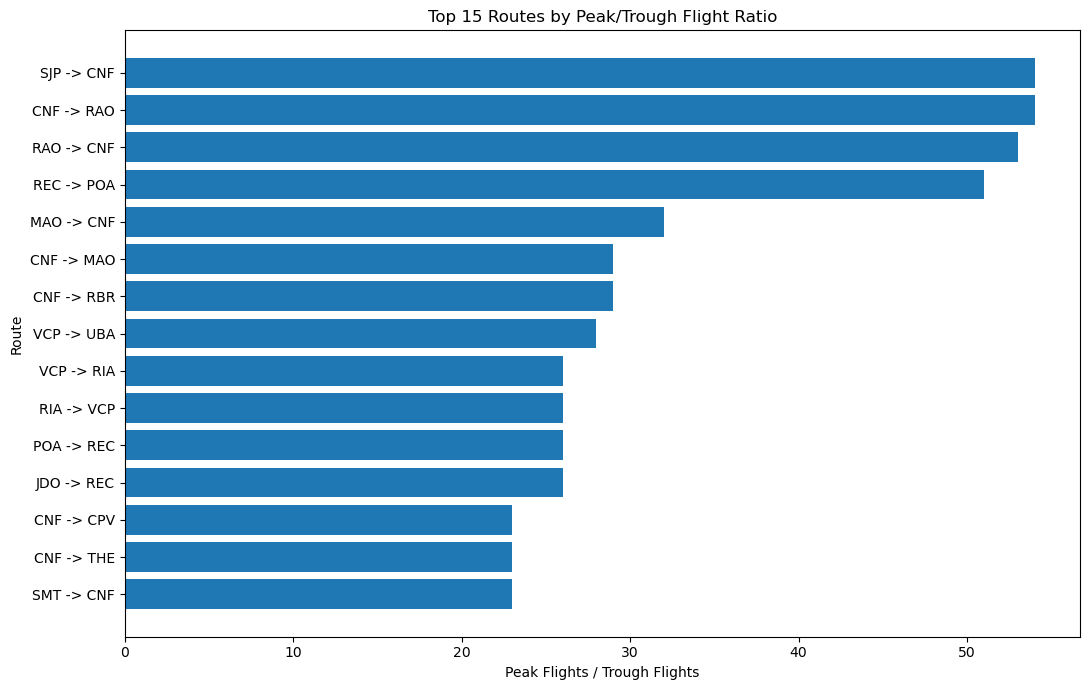

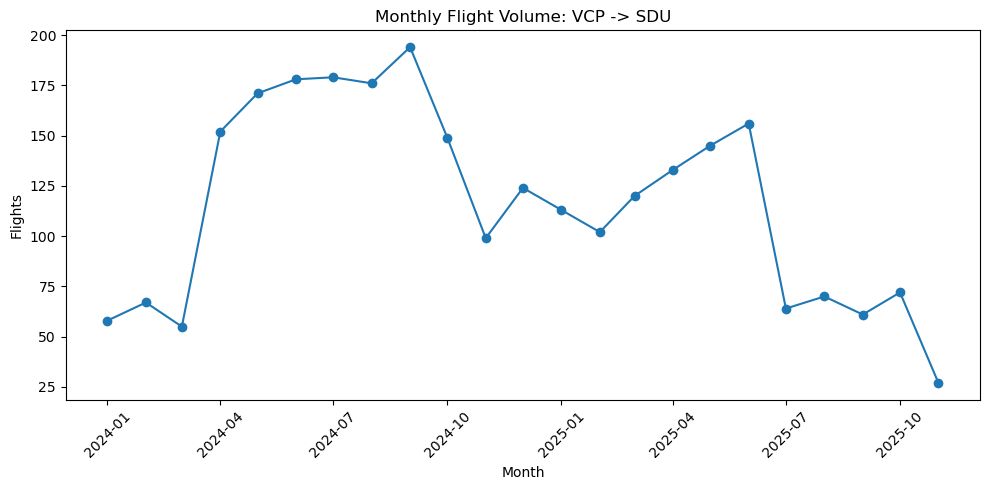

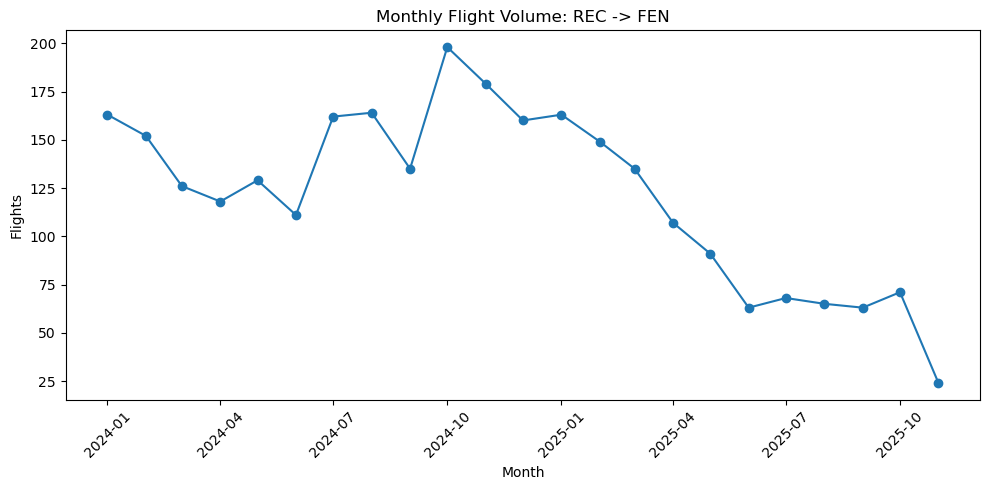

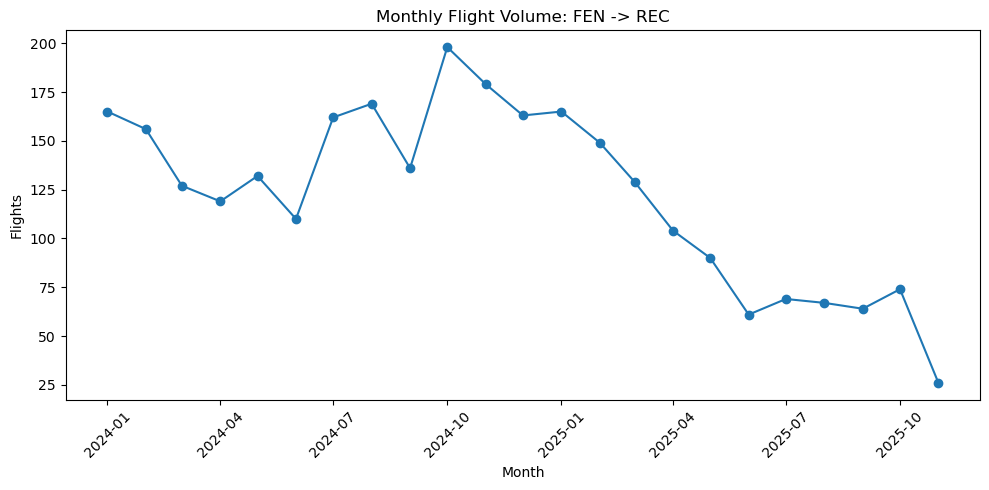

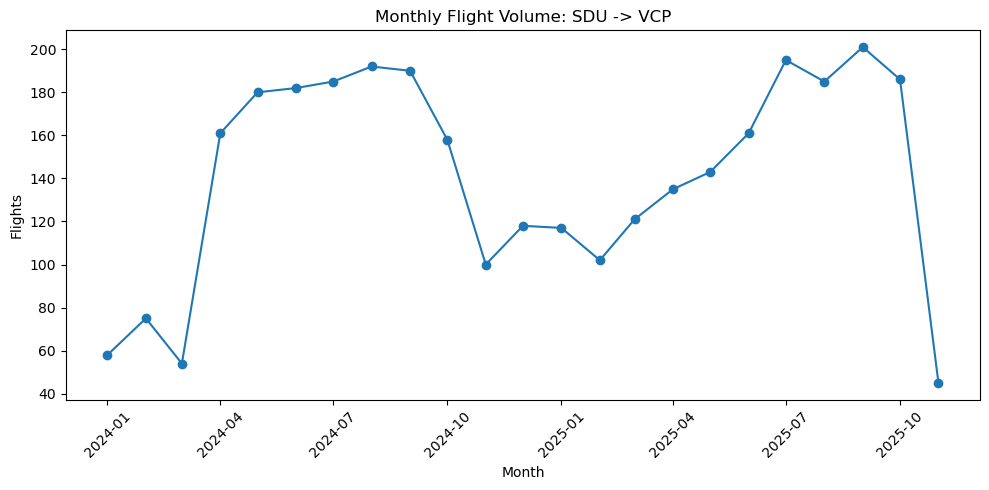

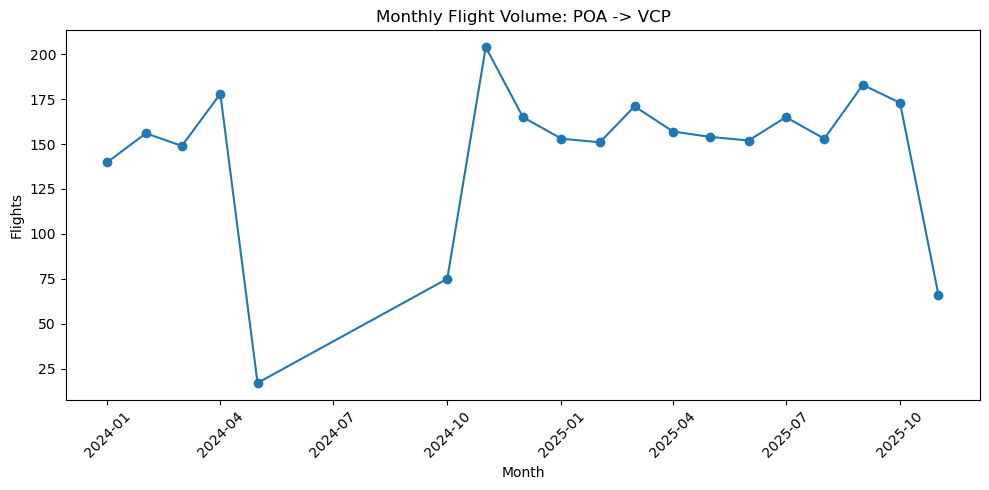

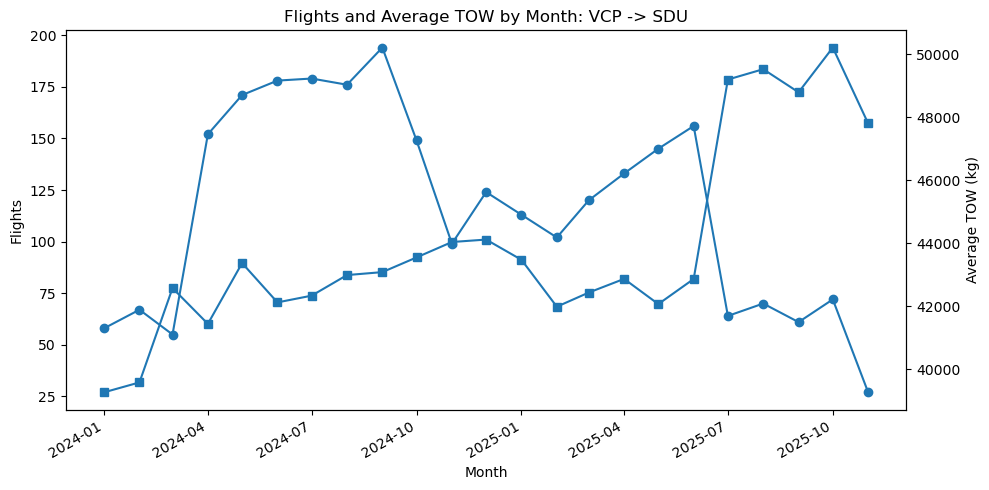

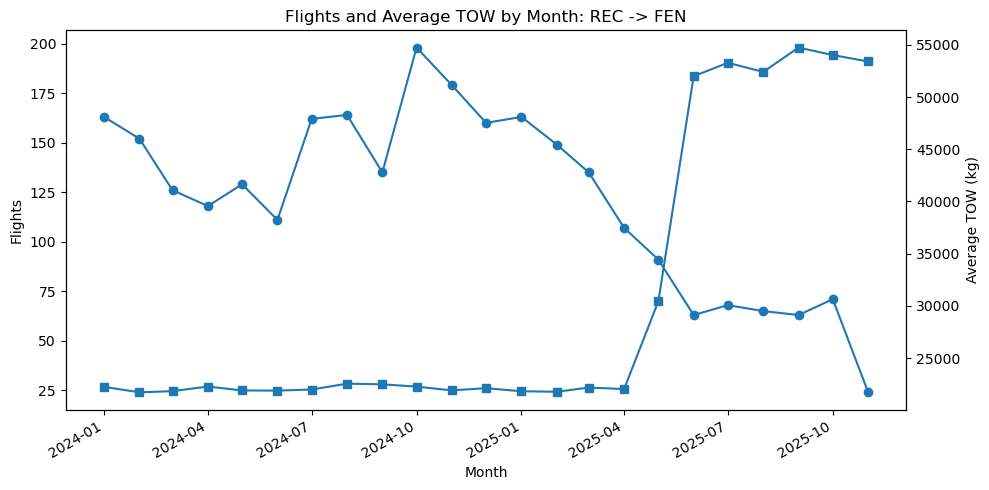

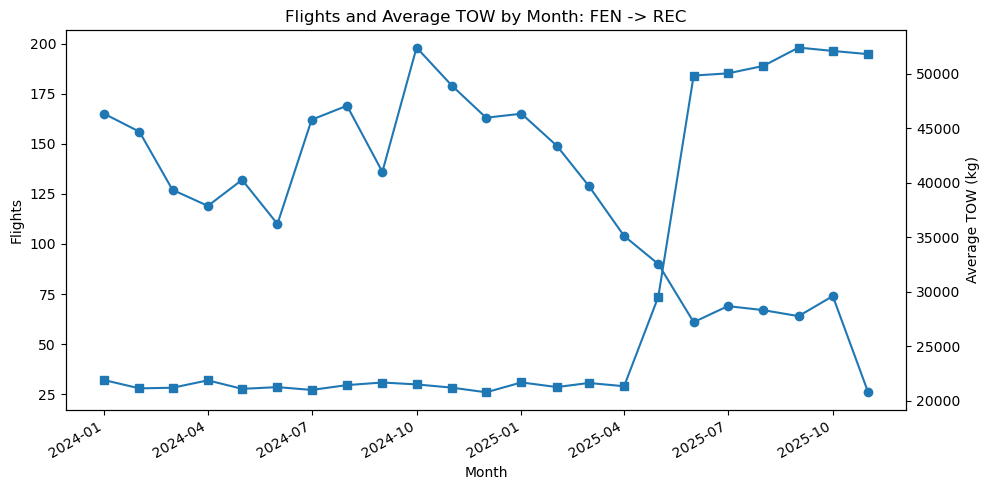

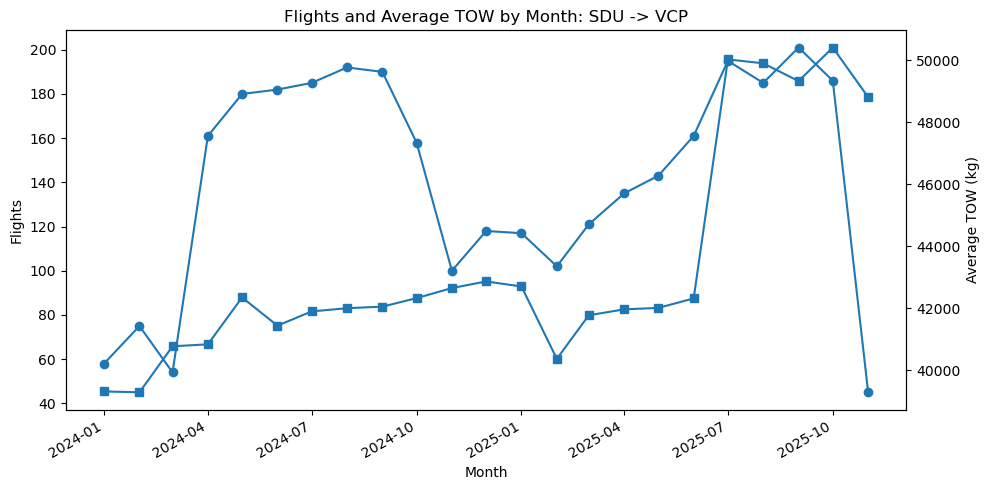

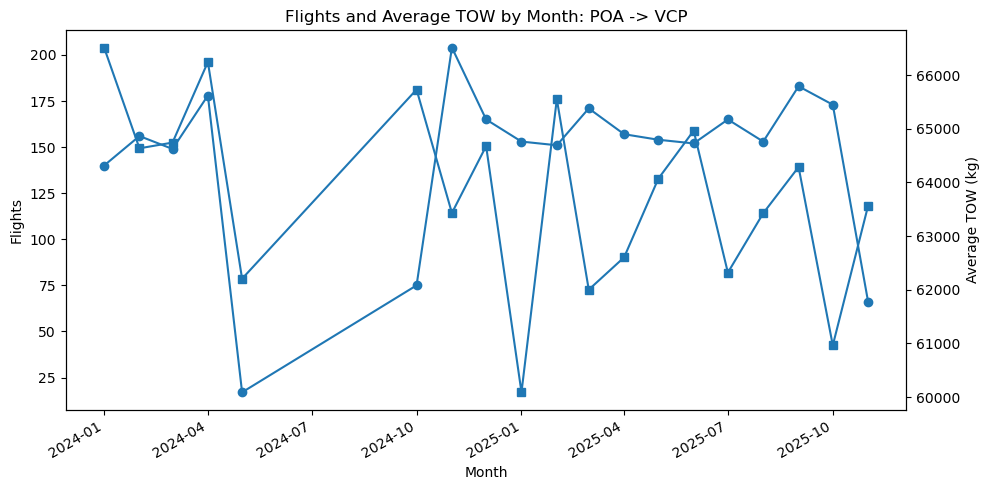

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 1. Load data
# =========================

FILE_PATH = "Azul_DataSample.xlsx"   # change if needed
OUTPUT_DIR = Path("azul_route_seasonality_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_excel(FILE_PATH)
df.columns = df.columns.str.strip()

# Core columns
DATE_COL = "STDUTC"
DEP_COL = "DepartureStation"
ARR_COL = "ArrivalStation"
EQUIP_COL = "Equipment"

# Optional operational columns
FUEL_COL = "TripFuelBurnTotal [KG]" if "TripFuelBurnTotal [KG]" in df.columns else None
DIST_COL = "GroundDistance [NM]" if "GroundDistance [NM]" in df.columns else None
TIME_COL = "TripTimeSec" if "TripTimeSec" in df.columns else None
TOW_COL = "TakeOffWeight  [KG]" if "TakeOffWeight  [KG]" in df.columns else (
    "TakeOffWeight [KG]" if "TakeOffWeight [KG]" in df.columns else None
)

# =========================
# 2. Basic parsing
# =========================

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL, DEP_COL, ARR_COL]).copy()

# =========================
# 3. Data cleaning
# =========================
# Adjust thresholds later if you want tighter filtering.

initial_rows = len(df)

# Remove negative or zero distance
if DIST_COL:
    df = df[df[DIST_COL].notna()]
    df = df[df[DIST_COL] > 0]

# Remove negative or zero fuel burn
if FUEL_COL:
    df = df[df[FUEL_COL].notna()]
    df = df[df[FUEL_COL] > 0]

# Remove impossible / unreasonably short trip times
# 10 minutes = 600 sec is a conservative lower bound
if TIME_COL:
    df = df[df[TIME_COL].notna()]
    df = df[df[TIME_COL] >= 600]

# Remove implausible TOW values
# This threshold is intentionally broad so it only removes obvious bad data
if TOW_COL:
    df = df[df[TOW_COL].notna()]
    df = df[df[TOW_COL] >= 5000]
    df = df[df[TOW_COL] <= 350000]

# Additional derived-rate cleaning
# These are useful for removing clearly broken records
if FUEL_COL and DIST_COL:
    df["FuelPerNM"] = df[FUEL_COL] / df[DIST_COL]
    df = df[df["FuelPerNM"].between(0.5, 50)]

if FUEL_COL and TIME_COL:
    df["FuelPerHour"] = df[FUEL_COL] * 3600 / df[TIME_COL]
    df = df[df["FuelPerHour"].between(100, 50000)]

# Optional speed sanity check
if DIST_COL and TIME_COL:
    df["GroundSpeedApprox"] = df[DIST_COL] / (df[TIME_COL] / 3600)
    df = df[df["GroundSpeedApprox"].between(80, 700)]

cleaned_rows = len(df)
rows_removed = initial_rows - cleaned_rows

print(f"Initial rows: {initial_rows}")
print(f"Rows after cleaning: {cleaned_rows}")
print(f"Rows removed: {rows_removed}")

# =========================
# 4. Time + route fields
# =========================

df["Route"] = df[DEP_COL].astype(str) + " -> " + df[ARR_COL].astype(str)
df["Year"] = df[DATE_COL].dt.year
df["Month"] = df[DATE_COL].dt.month
df["MonthStart"] = df[DATE_COL].dt.to_period("M").dt.to_timestamp()
df["MonthName"] = df[DATE_COL].dt.strftime("%b")
df["YearMonth"] = df[DATE_COL].dt.to_period("M").astype(str)

# =========================
# 5. Route-month demand table
# =========================

agg_dict = {
    "Flights": ("Route", "size"),
    "PrimaryEquipment": (EQUIP_COL, lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    "DistinctAircraft": (EQUIP_COL, "nunique"),
}

if FUEL_COL:
    agg_dict["FuelBurnKg"] = (FUEL_COL, "sum")
    agg_dict["AvgFuelBurnKg"] = (FUEL_COL, "mean")

if DIST_COL:
    agg_dict["AvgDistanceNM"] = (DIST_COL, "mean")

if TIME_COL:
    agg_dict["AvgTripTimeSec"] = (TIME_COL, "mean")

if TOW_COL:
    agg_dict["AvgTOW_kg"] = (TOW_COL, "mean")
    agg_dict["MaxTOW_kg"] = (TOW_COL, "max")
    agg_dict["TotalTOW_kg"] = (TOW_COL, "sum")

if "FuelPerNM" in df.columns:
    agg_dict["AvgFuelPerNM"] = ("FuelPerNM", "mean")

if "FuelPerHour" in df.columns:
    agg_dict["AvgFuelPerHour"] = ("FuelPerHour", "mean")

route_monthly = (
    df.groupby(["Route", "Year", "Month", "MonthStart"], as_index=False)
      .agg(**agg_dict)
      .sort_values(["Route", "MonthStart"])
)

# =========================
# 6. Seasonality scoring
# =========================

def seasonality_index(series):
    total = series.sum()
    if total <= 0:
        return np.nan
    share = series / total
    uniform = 1 / len(series)
    return np.abs(share - uniform).sum()

summary_rows = []

for route, g in route_monthly.groupby("Route"):
    g = g.sort_values("MonthStart").copy()
    flights = g["Flights"]

    peak_idx = flights.idxmax()
    trough_idx = flights.idxmin()

    mean_flights = flights.mean()
    std_flights = flights.std(ddof=0)
    cv = std_flights / mean_flights if mean_flights > 0 else np.nan

    row = {
        "Route": route,
        "ActiveMonths": len(g),
        "TotalFlights": flights.sum(),
        "AvgFlightsPerMonth": mean_flights,
        "StdFlightsPerMonth": std_flights,
        "CoeffVarFlights": cv,
        "PeakMonth": g.loc[peak_idx, "MonthStart"],
        "PeakFlights": g.loc[peak_idx, "Flights"],
        "TroughMonth": g.loc[trough_idx, "MonthStart"],
        "TroughFlights": g.loc[trough_idx, "Flights"],
        "PeakMinusTrough": g.loc[peak_idx, "Flights"] - g.loc[trough_idx, "Flights"],
        "PeakToTroughRatio": (
            g.loc[peak_idx, "Flights"] / g.loc[trough_idx, "Flights"]
            if g.loc[trough_idx, "Flights"] > 0 else np.nan
        ),
        "SeasonalityIndex": seasonality_index(flights),
    }

    # TOW-based peak behavior
    if TOW_COL:
        row["AvgMonthlyTOW_kg"] = g["AvgTOW_kg"].mean()
        row["PeakMonthAvgTOW_kg"] = g.loc[peak_idx, "AvgTOW_kg"]
        row["TroughMonthAvgTOW_kg"] = g.loc[trough_idx, "AvgTOW_kg"]
        row["PeakMonthTotalTOW_kg"] = g.loc[peak_idx, "TotalTOW_kg"]
        row["TroughMonthTotalTOW_kg"] = g.loc[trough_idx, "TotalTOW_kg"]

    summary_rows.append(row)

route_summary = pd.DataFrame(summary_rows)

# Composite ranking score
route_summary["VolatilityScore"] = (
    route_summary["CoeffVarFlights"].fillna(0)
    * np.log1p(route_summary["TotalFlights"])
    * np.sqrt(route_summary["PeakMinusTrough"].clip(lower=0))
)

route_summary = route_summary.sort_values(
    ["VolatilityScore", "TotalFlights"],
    ascending=[False, False]
)

# =========================
# 7. Peak-month TOW review
# =========================

median_flights = (
    route_monthly.groupby("Route")["Flights"]
    .median()
    .rename("MedianFlightsPerMonth")
    .reset_index()
)

peak_months = (
    route_monthly.sort_values(["Route", "Flights"], ascending=[True, False])
    .drop_duplicates("Route")
    .merge(median_flights, on="Route", how="left")
)

peak_months["FlightsAboveMedian"] = peak_months["Flights"] - peak_months["MedianFlightsPerMonth"]

if TOW_COL:
    median_tow = (
        route_monthly.groupby("Route")["AvgTOW_kg"]
        .median()
        .rename("MedianAvgTOW_kg")
        .reset_index()
    )
    peak_months = peak_months.merge(median_tow, on="Route", how="left")
    peak_months["AvgTOWIncreaseVsMedian"] = peak_months["AvgTOW_kg"] - peak_months["MedianAvgTOW_kg"]

    peak_months["PeakStrategyGuess"] = np.select(
        [
            (peak_months["FlightsAboveMedian"] >= 2) & (peak_months["AvgTOWIncreaseVsMedian"] > 2000),
            (peak_months["FlightsAboveMedian"] >= 2) & (peak_months["AvgTOWIncreaseVsMedian"] <= 2000),
            (peak_months["FlightsAboveMedian"] < 2) & (peak_months["AvgTOWIncreaseVsMedian"] > 2000),
        ],
        [
            "More flights + heavier departures",
            "More flights, little TOW increase",
            "Heavier departures, little frequency increase",
        ],
        default="Relatively stable"
    )

peak_months = peak_months.rename(columns={
    "MonthStart": "PeakMonth",
    "Flights": "PeakFlights"
})

# =========================
# 8. Route-month equipment and TOW mix
# =========================

mix_agg = {
    "Flights": ("Route", "size"),
}

if TOW_COL:
    mix_agg["AvgTOW_kg"] = (TOW_COL, "mean")
    mix_agg["TotalTOW_kg"] = (TOW_COL, "sum")

if FUEL_COL:
    mix_agg["FuelBurnKg"] = (FUEL_COL, "sum")

route_month_equipment = (
    df.groupby(["Route", "MonthStart", EQUIP_COL], as_index=False)
      .agg(**mix_agg)
      .sort_values(["Route", "MonthStart", "Flights"], ascending=[True, True, False])
)

# =========================
# 9. Save outputs
# =========================

route_monthly.to_csv(OUTPUT_DIR / "route_monthly_demand_cleaned.csv", index=False)
route_summary.to_csv(OUTPUT_DIR / "route_seasonality_summary_cleaned.csv", index=False)
peak_months.to_csv(OUTPUT_DIR / "route_peak_tow_review.csv", index=False)
route_month_equipment.to_csv(OUTPUT_DIR / "route_month_equipment_tow_mix.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "route_monthly_demand_cleaned.csv")
print(OUTPUT_DIR / "route_seasonality_summary_cleaned.csv")
print(OUTPUT_DIR / "route_peak_tow_review.csv")
print(OUTPUT_DIR / "route_month_equipment_tow_mix.csv")

# =========================
# 10. Useful plots
# =========================

# Top seasonal routes
top15 = route_summary.head(15).iloc[::-1]

plt.figure(figsize=(11, 7))
plt.barh(top15["Route"], top15["VolatilityScore"])
plt.title("Top 15 Routes by Seasonal Demand Volatility")
plt.xlabel("Volatility Score")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top15_route_volatility_cleaned.png", dpi=200)
plt.show()

# Top peak/trough ratio routes
plot_df = (
    route_summary.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["PeakToTroughRatio"])
    .query("ActiveMonths >= 6 and TotalFlights >= 12")
    .sort_values("PeakToTroughRatio", ascending=False)
    .head(15)
    .iloc[::-1]
)

plt.figure(figsize=(11, 7))
plt.barh(plot_df["Route"], plot_df["PeakToTroughRatio"])
plt.title("Top 15 Routes by Peak/Trough Flight Ratio")
plt.xlabel("Peak Flights / Trough Flights")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top15_peak_to_trough_cleaned.png", dpi=200)
plt.show()

# Top 5 route profiles
top_routes = route_summary.head(5)["Route"].tolist()

for route in top_routes:
    g = route_monthly[route_monthly["Route"] == route].sort_values("MonthStart")

    plt.figure(figsize=(10, 5))
    plt.plot(g["MonthStart"], g["Flights"], marker="o", label="Flights")
    plt.title(f"Monthly Flight Volume: {route}")
    plt.xlabel("Month")
    plt.ylabel("Flights")
    plt.xticks(rotation=45)
    plt.tight_layout()
    safe_name = route.replace(" ", "").replace("->", "_").replace("/", "_")
    plt.savefig(OUTPUT_DIR / f"route_profile_{safe_name}.png", dpi=200)
    plt.show()

# Optional TOW vs flights plot for top routes
if TOW_COL:
    for route in top_routes:
        g = route_monthly[route_monthly["Route"] == route].sort_values("MonthStart")

        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax1.plot(g["MonthStart"], g["Flights"], marker="o")
        ax1.set_xlabel("Month")
        ax1.set_ylabel("Flights")

        ax2 = ax1.twinx()
        ax2.plot(g["MonthStart"], g["AvgTOW_kg"], marker="s")
        ax2.set_ylabel("Average TOW (kg)")

        plt.title(f"Flights and Average TOW by Month: {route}")
        fig.autofmt_xdate()
        fig.tight_layout()
        safe_name = route.replace(" ", "").replace("->", "_").replace("/", "_")
        plt.savefig(OUTPUT_DIR / f"route_flights_tow_{safe_name}.png", dpi=200)
        plt.show()

  Aircraft  Flights      P10       P25   Median      P75      P90      IQR  \
2      ATR    78452  18948.0  20127.00  21225.0  21860.0  22304.9  1733.00   
3       E1    44805  40868.0  42851.00  44429.0  45480.0  46299.0  2629.00   
4       E2    50191  49129.0  51238.00  52745.0  54062.5  55191.0  2824.50   
0     A320   100865  61142.0  64185.00  66644.0  68988.0  70963.0  4803.00   
1     A321    13794  72751.0  76781.25  80116.5  82550.0  84299.1  5768.75   

   OperationalLow  OperationalHigh  
2         18948.0          22304.9  
3         40868.0          46299.0  
4         49129.0          55191.0  
0         61142.0          70963.0  
1         72751.0          84299.1  


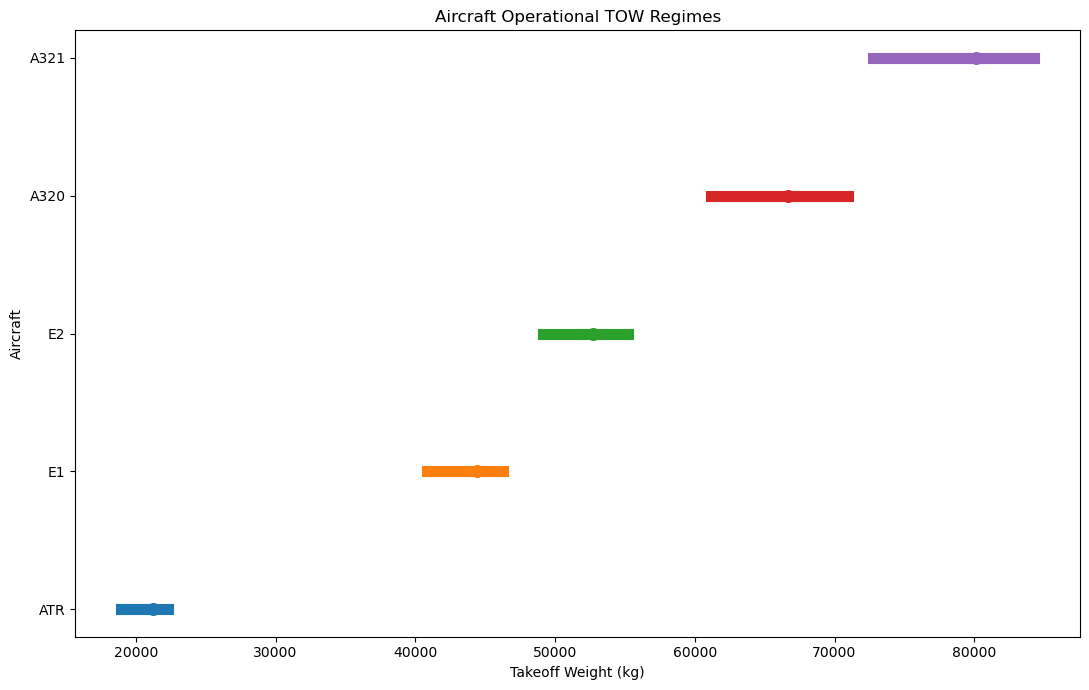

          Route  MonthsObserved  RegimesObserved             FirstRegime  \
189  REC -> REC              20                5  Outside Normal Regimes   
282  VCP -> VDC               2                2  Outside Normal Regimes   
10   BPS -> REC               3                2                    A320   
120  LDB -> REC               3                2  Outside Normal Regimes   
160  QNS -> VCP               6                3                     ATR   
40   CNF -> CNF              17                5  Outside Normal Regimes   
267  VCP -> QNS               6                3  Outside Normal Regimes   
161  RAO -> CNF              19                2  Outside Normal Regimes   
281  VCP -> VCP              23                3  Outside Normal Regimes   
112  JJD -> REC               2                2  Outside Normal Regimes   
21   CFB -> VCP               2                2  Outside Normal Regimes   
169  REC -> FEN              23                3                     ATR   
52   CNF -> 

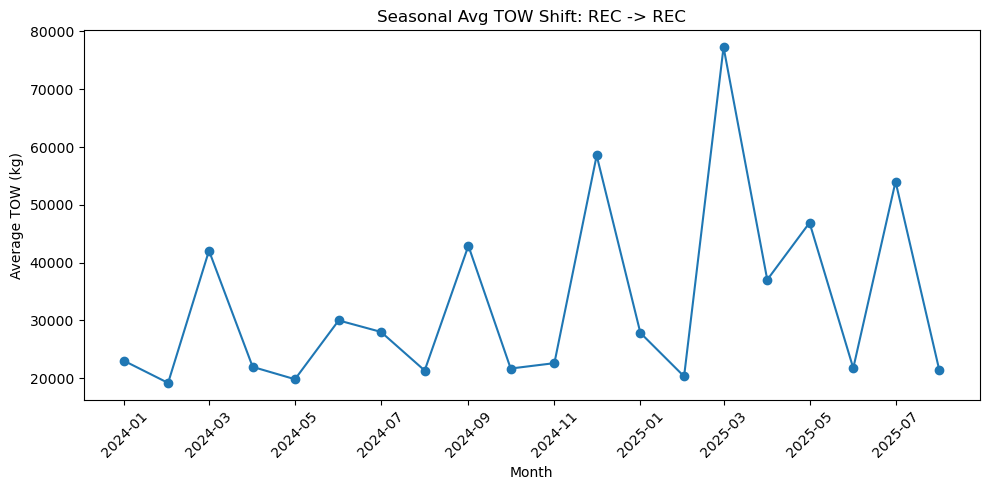

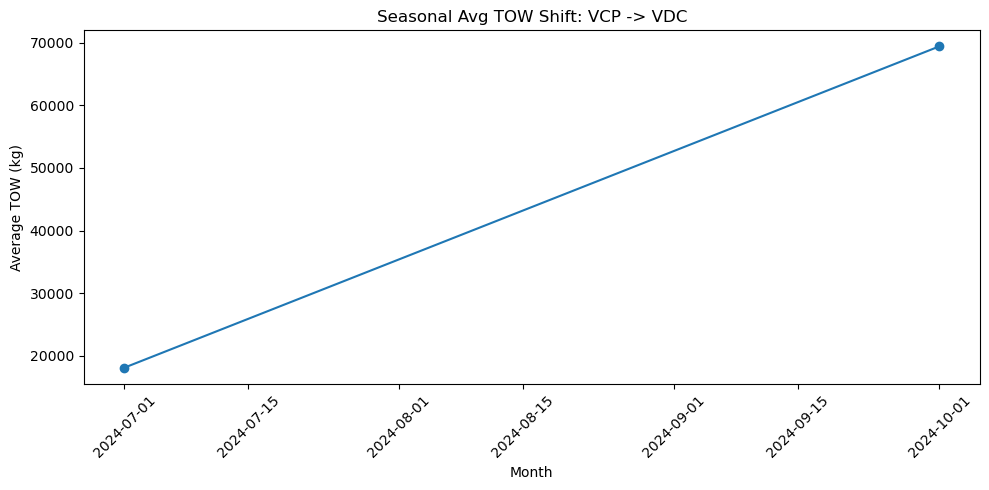

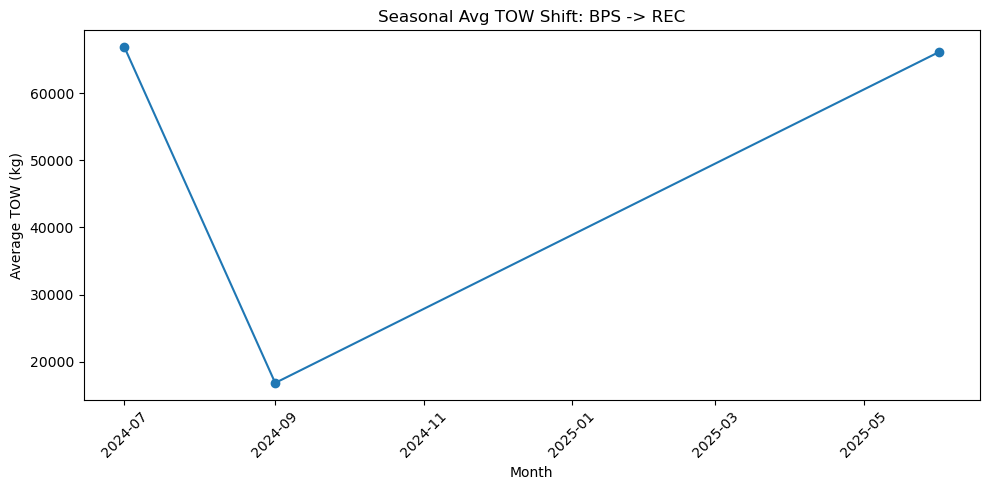

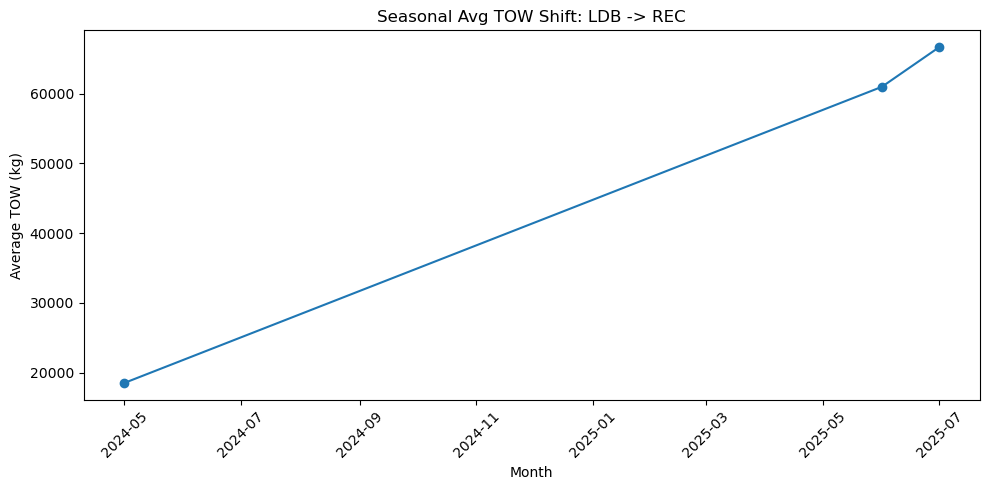

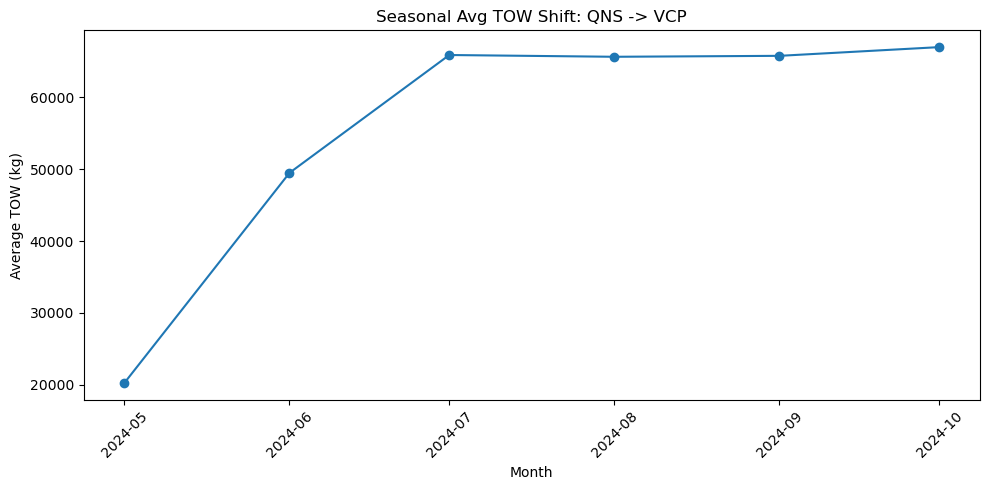

In [2]:
# ==========================================================
# Aircraft Operational Regime Detection using TOW
# ==========================================================
# Goal:
# Determine whether monthly route-level TOW shifts move into the
# normal operating regime of different aircraft types.
#
# Idea:
# For each aircraft type:
#   - Find where MOST flights occur in TOW space
#   - Use robust percentiles to remove outliers
#   - Define this as the aircraft's "operational regime"
#
# Then for each route-month:
#   - Compare AvgTOW_kg to those regimes
#   - Detect when a route shifts upward/downward into another regime
#
# This helps identify:
#   - seasonal upgauging
#   - seasonal downgauging
#   - whether Azul uses more flights or larger aircraft in peaks
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# Assumes df already loaded and cleaned from prior script
# Required:
# df with:
#   Equipment
#   TakeOffWeight [KG] or TakeOffWeight  [KG]
#   Route
#   MonthStart
# ----------------------------------------------------------

# Detect TOW column
TOW_COL = "TakeOffWeight  [KG]" if "TakeOffWeight  [KG]" in df.columns else "TakeOffWeight [KG]"

# ==========================================================
# 1. Build aircraft TOW operational regimes
# ==========================================================

# Robust percentiles:
# keep central 80% of operations (10th to 90th percentile)
# can tighten to 15/85 if desired

regime_rows = []

for aircraft, g in df.groupby("Equipment"):

    tow = g[TOW_COL].dropna()

    if len(tow) < 30:
        continue

    p10 = tow.quantile(0.10)
    p25 = tow.quantile(0.25)
    p50 = tow.quantile(0.50)
    p75 = tow.quantile(0.75)
    p90 = tow.quantile(0.90)

    iqr = p75 - p25

    regime_rows.append({
        "Aircraft": aircraft,
        "Flights": len(tow),
        "P10": p10,
        "P25": p25,
        "Median": p50,
        "P75": p75,
        "P90": p90,
        "IQR": iqr,
        "OperationalLow": p10,
        "OperationalHigh": p90
    })

regimes = pd.DataFrame(regime_rows).sort_values("Median")

print(regimes)

# Save
regimes.to_csv("aircraft_tow_operational_regimes.csv", index=False)

# ==========================================================
# 2. Plot Aircraft TOW Regimes
# ==========================================================

plt.figure(figsize=(11,7))

for i, row in regimes.iterrows():
    plt.plot(
        [row["OperationalLow"], row["OperationalHigh"]],
        [row["Aircraft"], row["Aircraft"]],
        linewidth=8
    )
    plt.scatter(row["Median"], row["Aircraft"], s=70)

plt.title("Aircraft Operational TOW Regimes")
plt.xlabel("Takeoff Weight (kg)")
plt.ylabel("Aircraft")

plt.tight_layout()
plt.show()

# ==========================================================
# 3. Add Route-Month AvgTOW
# ==========================================================

route_monthly_tow = (
    df.groupby(["Route","MonthStart"], as_index=False)
      .agg(
          Flights=("Route","size"),
          AvgTOW_kg=(TOW_COL,"mean"),
          MedianTOW_kg=(TOW_COL,"median"),
          PrimaryAircraft=("Equipment", lambda s: s.mode().iloc[0])
      )
)

# ==========================================================
# 4. Determine Which Aircraft Regime Each Route-Month Falls In
# ==========================================================

def classify_regime(avg_tow):

    matches = []

    for _, row in regimes.iterrows():

        if row["OperationalLow"] <= avg_tow <= row["OperationalHigh"]:
            matches.append(row["Aircraft"])

    if len(matches) == 0:
        return "Outside Normal Regimes"

    return ", ".join(matches)

route_monthly_tow["TowRegime"] = route_monthly_tow["AvgTOW_kg"].apply(classify_regime)

# Save
route_monthly_tow.to_csv("route_month_tow_regimes.csv", index=False)

# ==========================================================
# 5. Detect Seasonal Regime Changes by Route
# ==========================================================

seasonal_changes = []

for route, g in route_monthly_tow.groupby("Route"):

    g = g.sort_values("MonthStart")

    first_regime = g.iloc[0]["TowRegime"]
    last_regime = g.iloc[-1]["TowRegime"]

    unique_regimes = g["TowRegime"].nunique()

    if unique_regimes > 1:

        seasonal_changes.append({
            "Route": route,
            "MonthsObserved": len(g),
            "RegimesObserved": unique_regimes,
            "FirstRegime": first_regime,
            "LastRegime": last_regime,
            "MinAvgTOW": g["AvgTOW_kg"].min(),
            "MaxAvgTOW": g["AvgTOW_kg"].max(),
            "DeltaTOW": g["AvgTOW_kg"].max() - g["AvgTOW_kg"].min()
        })

seasonal_changes = pd.DataFrame(seasonal_changes).sort_values("DeltaTOW", ascending=False)

seasonal_changes.to_csv("seasonal_route_regime_changes.csv", index=False)

print(seasonal_changes.head(20))

# ==========================================================
# 6. Visualize Best Candidate Routes
# ==========================================================

top_routes = seasonal_changes.head(5)["Route"].tolist()

for route in top_routes:

    g = route_monthly_tow[route_monthly_tow["Route"] == route].sort_values("MonthStart")

    plt.figure(figsize=(10,5))

    plt.plot(g["MonthStart"], g["AvgTOW_kg"], marker="o")

    plt.title(f"Seasonal Avg TOW Shift: {route}")
    plt.xlabel("Month")
    plt.ylabel("Average TOW (kg)")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()